In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

PROCESSED_PATH = "../data/processed/"
VISUAL_PATH = "../visualization/"

In [3]:
df = pd.read_csv(PROCESSED_PATH + "ecommerce_main_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (113425, 42)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score,order_year,order_month,order_month_name,order_year_month,delivery_time_days,estimated_delivery_days,is_late_delivery,is_delivered
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP,38.71,1.0,voucher,4.0,2017,10,October,2017-10,8.0,15,0,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP,141.46,1.0,boleto,4.0,2018,7,July,2018-07,13.0,19,0,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP,179.12,3.0,credit_card,5.0,2018,8,August,2018-08,9.0,26,0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,31842.0,belo horizonte,MG,72.20,1.0,credit_card,5.0,2017,11,November,2017-11,13.0,26,0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,8752.0,mogi das cruzes,SP,28.62,1.0,credit_card,5.0,2018,2,February,2018-02,2.0,12,0,1


In [4]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [5]:
df_delivered = df[df["order_status"] == "delivered"].copy()

print("Original data:", df.shape)
print("Delivered data:", df_delivered.shape)

Original data: (113425, 42)
Delivered data: (110197, 42)


In [6]:
total_revenue = df_delivered["payment_value"].sum()
total_orders = df_delivered["order_id"].nunique()
total_customers = df_delivered["customer_unique_id"].nunique()
total_products = df_delivered["product_id"].nunique()
total_sellers = df_delivered["seller_id"].nunique()
avg_order_value = total_revenue / total_orders
avg_review_score = df_delivered["review_score"].mean()
avg_delivery_time = df_delivered["delivery_time_days"].mean()

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Total Sellers",
        "Average Order Value",
        "Average Review Score",
        "Average Delivery Time"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        total_products,
        total_sellers,
        avg_order_value,
        avg_review_score,
        avg_delivery_time
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,1.977616e+07
1,Total Orders,9.647800e+04
2,Total Customers,9.335800e+04
3,Total Products,3.221600e+04
4,Total Sellers,2.970000e+03
5,Average Order Value,2.049810e+02
6,Average Review Score,4.082044e+00
7,Average Delivery Time,1.200734e+01


In [7]:
monthly_revenue = df_delivered.groupby("order_year_month", as_index=False).agg({
    "payment_value": "sum",
    "order_id": "nunique"
})

monthly_revenue = monthly_revenue.rename(columns={
    "payment_value": "total_revenue",
    "order_id": "total_orders"
})

monthly_revenue.head()

,order_year_month,total_revenue,total_orders
0,2016-09,0.00,1
1,2016-10,61746.94,265
2,2016-12,19.62,1
3,2017-01,176491.49,750
4,2017-02,325782.66,1653


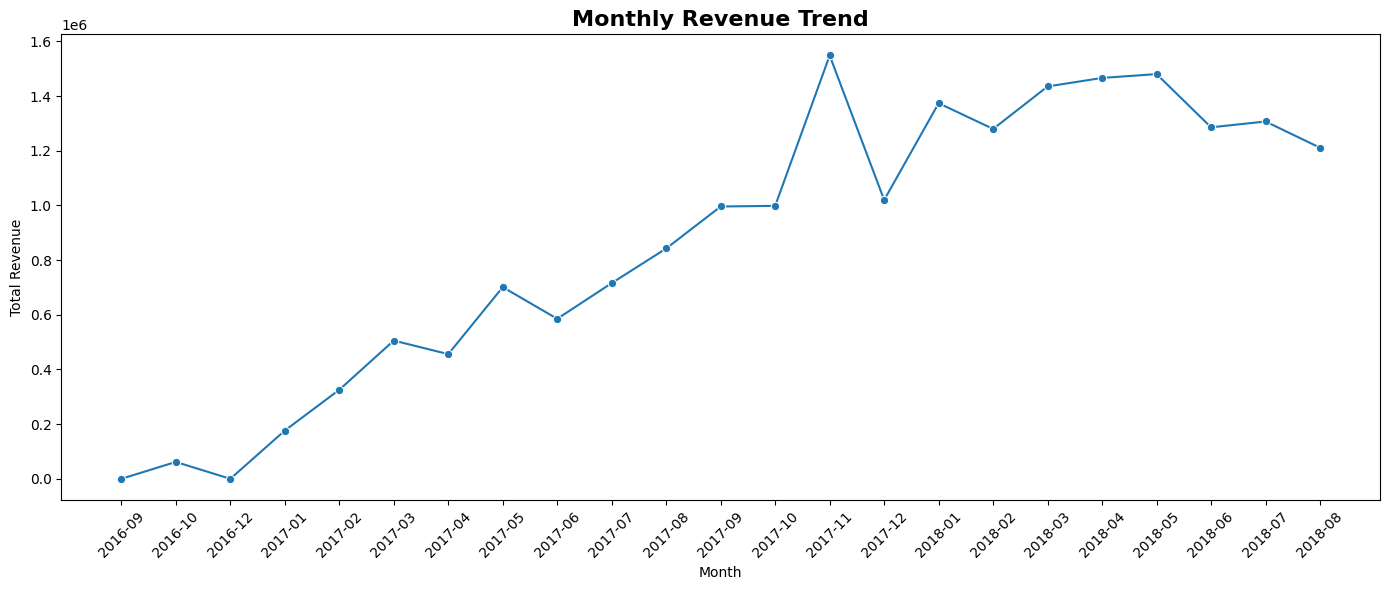

In [8]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_revenue, x="order_year_month", y="total_revenue", marker="o")

plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(VISUAL_PATH + "monthly_revenue_trend.png", dpi=300)
plt.show()

In [9]:
top_category = df_delivered.groupby("product_category_name_english", as_index=False).agg({
    "payment_value": "sum",
    "order_id": "nunique"
})

top_category = top_category.rename(columns={
    "payment_value": "total_revenue",
    "order_id": "total_orders"
})

top_category = top_category.sort_values(by="total_revenue", ascending=False).head(10)

top_category

,product_category_name_english,total_revenue,total_orders
7,bed_bath_table,1692714.28,9272
43,health_beauty,1620684.04,8647
15,computers_accessories,1549372.59,6530
39,furniture_decor,1394466.93,6307
70,watches_gifts,1387362.45,5495
65,sports_leisure,1349446.93,7530
49,housewares,1069787.97,5743
5,auto,833745.67,3810
42,garden_tools,810614.93,3448
20,cool_stuff,744649.32,3559


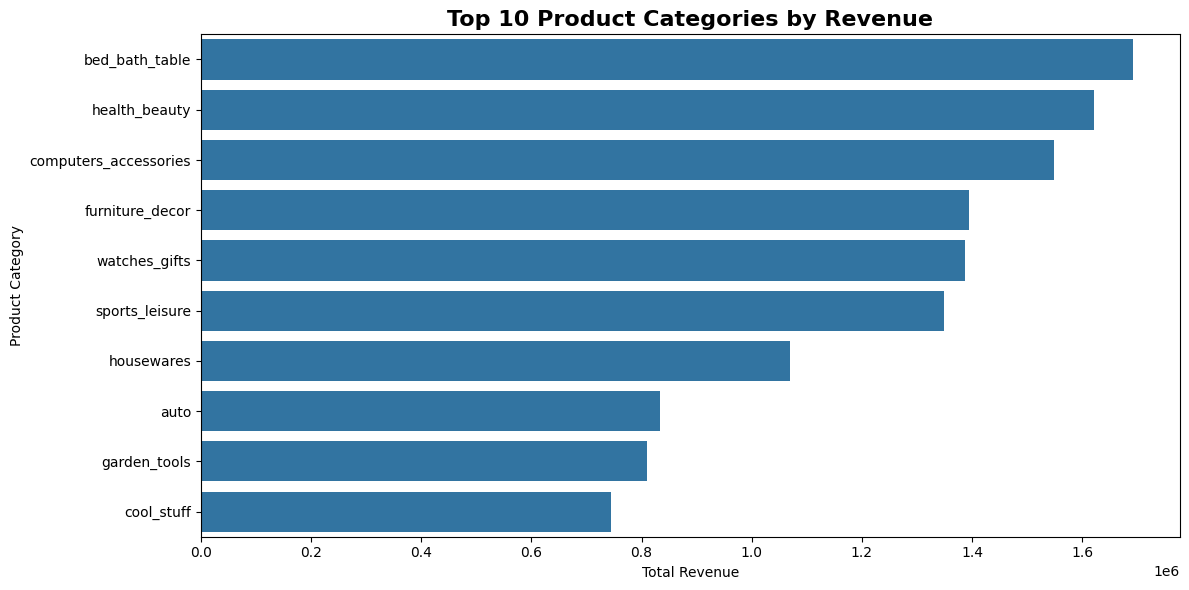

In [10]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_category,
    x="total_revenue",
    y="product_category_name_english"
)

plt.title("Top 10 Product Categories by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "top_product_categories.png", dpi=300)
plt.show()

In [11]:
top_state = df_delivered.groupby("customer_state", as_index=False).agg({
    "payment_value": "sum",
    "order_id": "nunique",
    "customer_unique_id": "nunique"
})

top_state = top_state.rename(columns={
    "payment_value": "total_revenue",
    "order_id": "total_orders",
    "customer_unique_id": "total_customers"
})

top_state = top_state.sort_values(by="total_revenue", ascending=False).head(10)

top_state

,customer_state,total_revenue,total_orders,total_customers
25,SP,7403993.29,40501,39156
18,RJ,2688933.90,12350,11917
10,MG,2281229.16,11354,11001
22,RS,1110976.47,5345,5168
17,PR,1030822.39,4923,4769
4,BA,773182.02,3256,3158
23,SC,767093.97,3546,3449
8,GO,493068.70,1957,1895
6,DF,421374.86,2080,2019
7,ES,398321.90,1995,1928


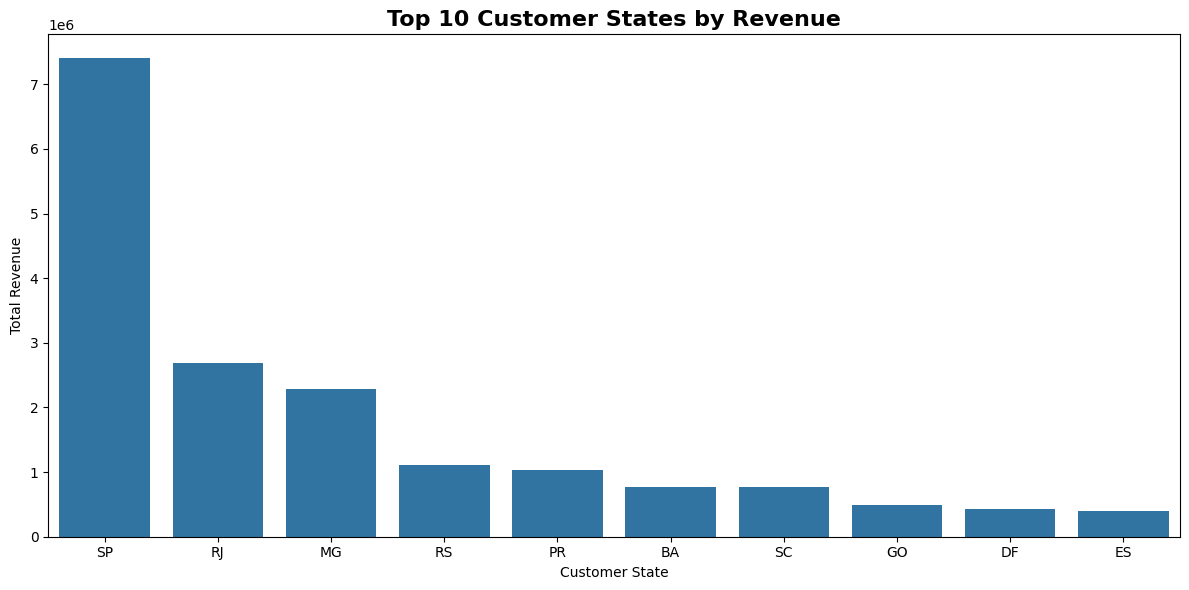

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_state,
    x="customer_state",
    y="total_revenue"
)

plt.title("Top 10 Customer States by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Customer State")
plt.ylabel("Total Revenue")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "top_customer_states.png", dpi=300)
plt.show()

In [14]:
payment_dist = df_delivered.groupby("payment_type", as_index=False).agg({
    "order_id": "nunique",
    "payment_value": "sum"
})

payment_dist = payment_dist.rename(columns={
    "order_id": "total_orders",
    "payment_value": "total_revenue"
})

payment_dist = payment_dist.sort_values(by="total_orders", ascending=False)

payment_dist

,payment_type,total_orders,total_revenue
1,credit_card,73941,15341260.68
0,boleto,19191,3943080.78
3,voucher,1861,245141.47
2,debit_card,1484,246677.51


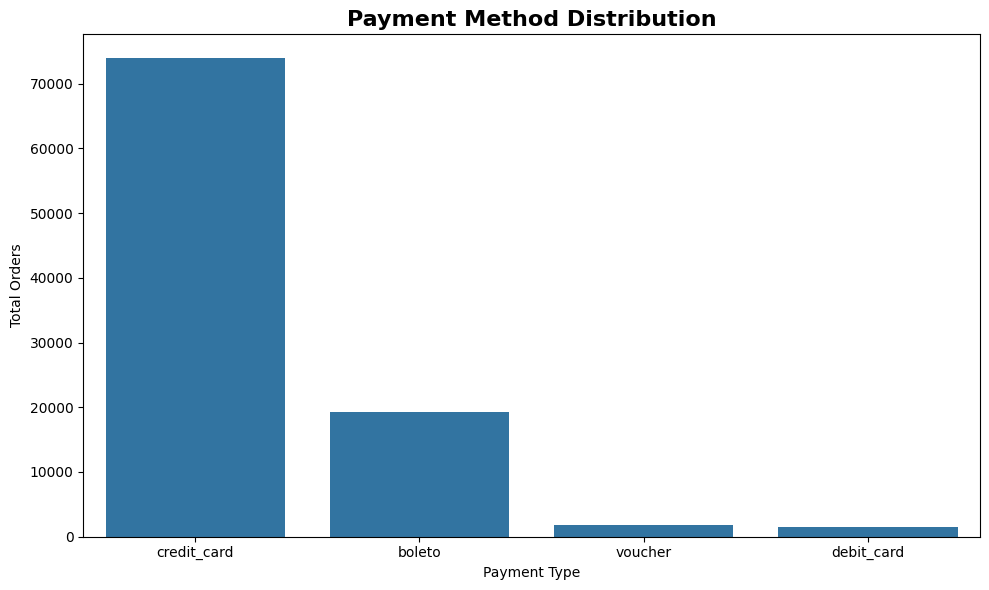

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=payment_dist,
    x="payment_type",
    y="total_orders"
)

plt.title("Payment Method Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Payment Type")
plt.ylabel("Total Orders")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "payment_method_distribution.png", dpi=300)
plt.show()

In [18]:
# Buat copy agar tidak mengubah df utama
df_review = df_delivered.copy()

# Bulatkan review_score agar kembali menjadi kategori 1-5
df_review["review_score_rounded"] = df_review["review_score"].round().astype("Int64")

# Hitung distribusi review score
review_distribution = df_review.groupby("review_score_rounded", as_index=False).agg({
    "order_id": "nunique"
})

review_distribution = review_distribution.rename(columns={
    "review_score_rounded": "review_score",
    "order_id": "total_orders"
})

review_distribution

,review_score,total_orders
0,1,9313
1,2,2954
2,3,7916
3,4,18945
4,5,56704


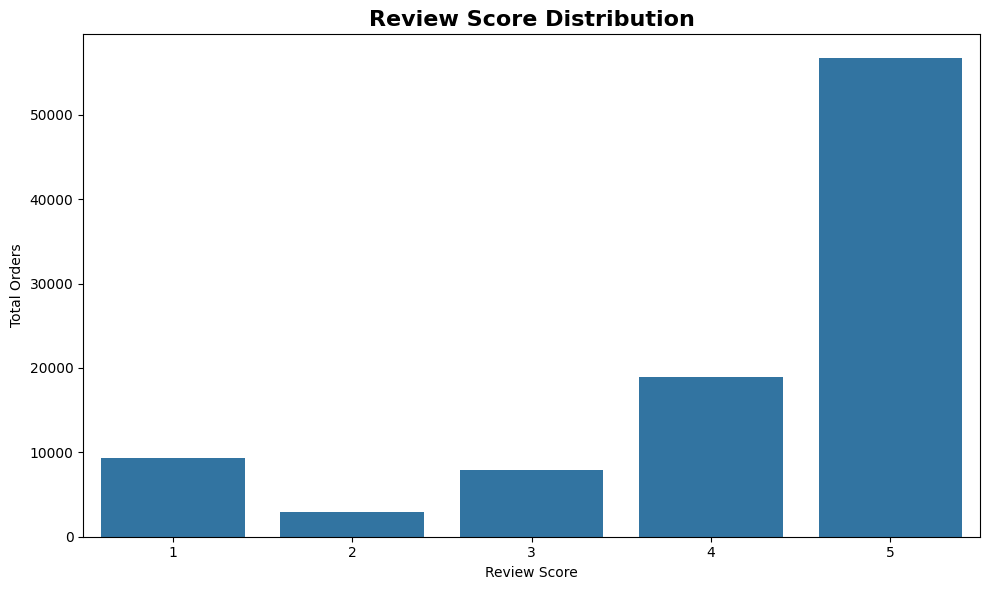

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=review_distribution,
    x="review_score",
    y="total_orders"
)

plt.title("Review Score Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Review Score")
plt.ylabel("Total Orders")
plt.xticks([0, 1, 2, 3, 4], ["1", "2", "3", "4", "5"])
plt.tight_layout()

plt.savefig(VISUAL_PATH + "review_score_distribution.png", dpi=300)
plt.show()

In [20]:
delivery_summary = df_delivered.groupby("is_late_delivery", as_index=False).agg({
    "order_id": "nunique",
    "review_score": "mean",
    "delivery_time_days": "mean"
})

delivery_summary["delivery_status"] = delivery_summary["is_late_delivery"].map({
    0: "On Time / Early",
    1: "Late"
})

delivery_summary

,is_late_delivery,order_id,review_score,delivery_time_days,delivery_status
0,0,88652,4.211551,10.386174,On Time / Early
1,1,7826,2.548891,30.885931,Late


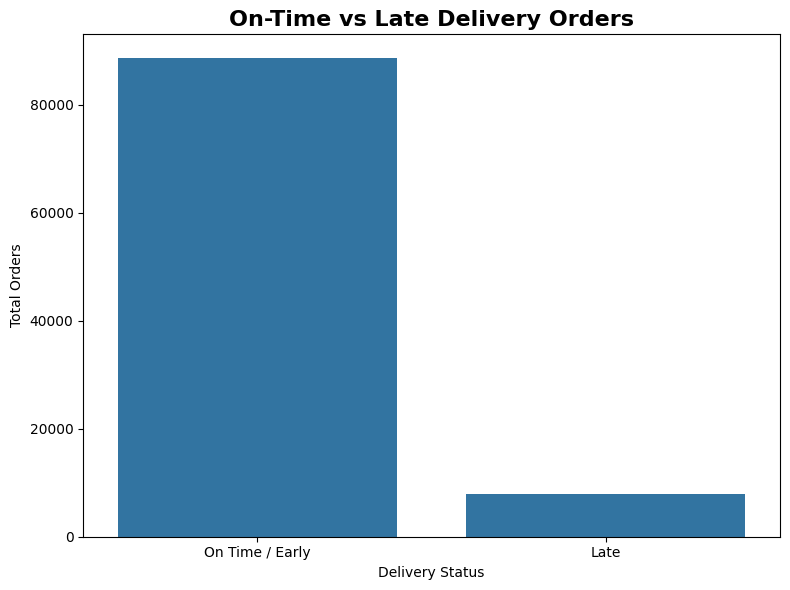

In [21]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=delivery_summary,
    x="delivery_status",
    y="order_id"
)

plt.title("On-Time vs Late Delivery Orders", fontsize=16, fontweight="bold")
plt.xlabel("Delivery Status")
plt.ylabel("Total Orders")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "delivery_performance.png", dpi=300)
plt.show()

In [22]:
kpi_summary.to_csv(PROCESSED_PATH + "kpi_summary.csv", index=False)
monthly_revenue.to_csv(PROCESSED_PATH + "monthly_revenue.csv", index=False)
top_category.to_csv(PROCESSED_PATH + "top_product_categories.csv", index=False)
top_state.to_csv(PROCESSED_PATH + "top_customer_states.csv", index=False)
payment_dist.to_csv(PROCESSED_PATH + "payment_distribution.csv", index=False)
review_distribution.to_csv(PROCESSED_PATH + "review_distribution.csv", index=False)
delivery_summary.to_csv(PROCESSED_PATH + "delivery_summary.csv", index=False)

print("All EDA summary files saved successfully!")

All EDA summary files saved successfully!


In [23]:
kpi_summary

,Metric,Value
0,Total Revenue,1.977616e+07
1,Total Orders,9.647800e+04
2,Total Customers,9.335800e+04
3,Total Products,3.221600e+04
4,Total Sellers,2.970000e+03
5,Average Order Value,2.049810e+02
6,Average Review Score,4.082044e+00
7,Average Delivery Time,1.200734e+01


In [24]:
monthly_revenue.sort_values(by="total_revenue", ascending=False).head(10)

,order_year_month,total_revenue,total_orders
13,2017-11,1548682.69,7289
19,2018-05,1480667.59,6749
18,2018-04,1466607.15,6798
17,2018-03,1435458.33,7003
15,2018-01,1374064.02,7069
21,2018-07,1307228.18,6159
20,2018-06,1285926.11,6099
16,2018-02,1279970.45,6555
22,2018-08,1211240.09,6351
14,2017-12,1020067.26,5513


In [25]:
top_state

,customer_state,total_revenue,total_orders,total_customers
25,SP,7403993.29,40501,39156
18,RJ,2688933.90,12350,11917
10,MG,2281229.16,11354,11001
22,RS,1110976.47,5345,5168
17,PR,1030822.39,4923,4769
4,BA,773182.02,3256,3158
23,SC,767093.97,3546,3449
8,GO,493068.70,1957,1895
6,DF,421374.86,2080,2019
7,ES,398321.90,1995,1928


In [26]:
top_category

,product_category_name_english,total_revenue,total_orders
7,bed_bath_table,1692714.28,9272
43,health_beauty,1620684.04,8647
15,computers_accessories,1549372.59,6530
39,furniture_decor,1394466.93,6307
70,watches_gifts,1387362.45,5495
65,sports_leisure,1349446.93,7530
49,housewares,1069787.97,5743
5,auto,833745.67,3810
42,garden_tools,810614.93,3448
20,cool_stuff,744649.32,3559


In [27]:
delivery_summary

,is_late_delivery,order_id,review_score,delivery_time_days,delivery_status
0,0,88652,4.211551,10.386174,On Time / Early
1,1,7826,2.548891,30.885931,Late
